In [1]:

!pip install qiskit_qasm3_import
!pip install qiskit qiskit[visualization] networkx pymetis matplotlib pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 20.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c8185e8f44a55d0a9e771c9eb82bdb0cf9596a7ce14eae43c4f3c0b29f121a41
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [6]:
import random
from qiskit import QuantumCircuit
from qiskit.qasm2 import dumps
num_qubits=int(input("Enter the total number of qubits: "))
num_cz_gates=int(input("Enter the total number of gates: "))

def generate_random_cz_circuit_qasm2(
    num_qubits,
    num_cz_gates,
    filename="random_12q_cz.qasm"
):
    # Create circuit
    qc = QuantumCircuit(num_qubits)

    # Add random CZ gates
    for _ in range(num_cz_gates):
        q1, q2 = random.sample(range(num_qubits), 2)
        qc.cz(q1, q2)

    # Print circuit
    print(qc.draw())

    # Export to OpenQASM 2.0
    qasm_str = dumps(qc)

    # Save to file
    with open(filename, "w") as f:
        f.write(qasm_str)

    print(f"\nSaved OpenQASM 2.0 circuit to '{filename}'")

    return qc

qc = generate_random_cz_circuit_qasm2(num_qubits,num_cz_gates)
# from google.colab import files
# files.download("random_12q_cz.qasm")
# from google.colab import files
# uploaded=files.upload()
# qc=QuantumCircuit.from_qasm_file("circuit_60q_600g.qasm")



Enter the total number of qubits: 60
Enter the total number of gates: 900
                                                                              »
 q_0: ────────────────────────────────────────────────────■───────────────────»
                                                          │                   »
 q_1: ─────────────────────────────────────────────────■──■───────────────────»
                                                       │                      »
 q_2: ──────────■──────────────────────────────────────┼──────────────────────»
                │                                      │                      »
 q_3: ──────────┼───────────────────────────────────■──┼──────────────────────»
                │                                   │  │                      »
 q_4: ──────────┼───────────■─────────────────■─────┼──┼──────────────────────»
                │           │                 │     │  │                      »
 q_5: ──────────┼───────────┼─────────────────

In [7]:
import networkx as nx
G = nx.Graph()
G = nx.convert_node_labels_to_integers(G)

for i in range(qc.num_qubits):
    G.add_node(i)

for instr in qc.data:

    operation = instr.operation
    qargs = instr.qubits

    if operation.num_qubits == 2:

        q1 = qc.find_bit(qargs[0]).index
        q2 = qc.find_bit(qargs[1]).index

        if G.has_edge(q1, q2):
            G[q1][q2]["weight"] += 1
        else:
            G.add_edge(q1, q2, weight=1)


/tmp/ipykernel_393/1718429311.py:28: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


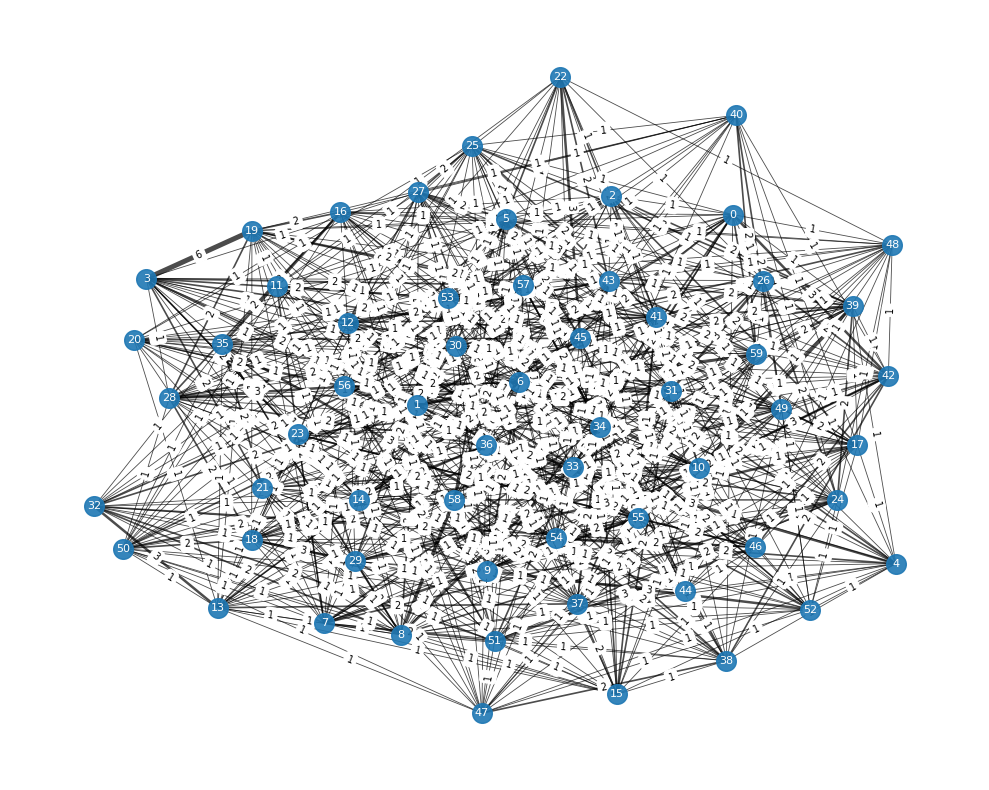

In [8]:
import matplotlib.pyplot as plt
remote_color_map = {
    (0,1): "red",
    (1,0): "red",
    (0,2): "green",
    (2,0): "green",
    (1,2): "blue",
    (2,1): "blue"
}

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)

weights = [G[u][v]['weight'] for u,v in G.edges()]
edge_widths = [w * 0.6 for w in weights]


# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=200,
    node_color="#1f78b4",
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.7,
    connectionstyle="arc3,rad=0.1"
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_color="white"
)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.axis("off")
plt.tight_layout()
plt.show()


In [10]:
num_qpu=int(input("Enter the number of Qpu's: "))
qubit_capacity=[]
sum=0
tpwgts=[] #parameter to pass to the metis software so that during partitioning it respects the qubit capacity for each qpu/partition

for i in range(num_qpu):
  data=int(input(f"Enter the number of data qubits for Qpu {i} "))
  while True:
        comm = int(input(f"Enter the number of communication qubits for Qpu {i}: "))
        if comm >= data:
            break
        else:
            print(f"Communication qubits must be >= data qubits ({data}) for worst case. Please re-enter.")

  qubit_capacity.append((data,comm))
  tpwgts.append(data/num_qubits)
  sum+=data

#checking if the total capacity doesnt surpass the number of qubits in the circuit
if sum > num_qubits:
  print("The capacity exceeds the total number of qubits in the circuit")

Enter the number of Qpu's: 3
Enter the number of data qubits for Qpu 0 30
Enter the number of communication qubits for Qpu 0: 30
Enter the number of data qubits for Qpu 1 17
Enter the number of communication qubits for Qpu 1: 20
Enter the number of data qubits for Qpu 2 25
Enter the number of communication qubits for Qpu 2: 25
The capacity exceeds the total number of qubits in the circuit


In [11]:
import pymetis

xadj = [0]
adjncy = []
eweights = []

for i in range(G.number_of_nodes()):

    neighbors = list(G.neighbors(i))

    for j in neighbors:
        adjncy.append(j)
        eweights.append(int(G[i][j]["weight"]))

    xadj.append(len(adjncy))


In [12]:
cut, partition = pymetis.part_graph(
    num_qpu,
    xadj=xadj,
    adjncy=adjncy,
    eweights=eweights,
    #tpwgts=tpwgts
)
partition = list(partition)
num_nodes = G.number_of_nodes()

assert len(partition) == num_nodes, "Partition size mismatch!"

print("Edge cut cost:", cut)
print("Partition assignment:", partition)

size_partition = [0] * num_qpu

for i in range(len(partition)):
    size_partition[partition[i]] += 1

for i in range(num_qpu):
    print(f"QPU{i} size: {size_partition[i]}")
    if size_partition[i] > qubit_capacity[i][0]:
        print(f"WARNING: Capacity exceeded for QPU{i}! Has {size_partition[i]} qubits but capacity is {qubit_capacity[i][0]}")

Edge cut cost: 490
Partition assignment: [0, 0, 2, 2, 0, 2, 2, 1, 1, 0, 2, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 2]
QPU0 size: 20
QPU1 size: 19
QPU2 size: 21


/tmp/ipykernel_393/2890761939.py:1: DeprecationWarning: Passing xadj/adjncy is deprecated and will be removed in 2027. Pass a CSRAdjacency object instead.
  cut, partition = pymetis.part_graph(


In [13]:
def compute_gain(G, partition, q, target, alpha=1.0):
    gain = 0

    for nbr in G.neighbors(q):
        w = G[q][nbr]["weight"]

        if partition[nbr] == target:
            gain += w
        if partition[nbr] == partition[q]:
            gain -= w

    # balance penalty
    size_target = partition.count(target)
    size_current = partition.count(partition[q])

    gain -= alpha * (size_target - size_current)

    return gain


In [14]:
#local sum of weights of all qubits
local=[0]*num_qubits
for q in range(num_qubits):
  sum=0
  for node in G.neighbors(q):
    if partition[q]==partition[node]:
      sum+=G[node][q]["weight"]

  local[q]=sum


In [15]:
# Best gain from Qpu_i to Qpu_j
def best_gain_between_qpu(source, target):
  best_gain=-1e9
  for i in range(len(partition)):
    if partition[i]==source:
      temp_gain=compute_gain(G, partition,i,target,alpha=0) # not using the balance penalty
      if best_gain < temp_gain:
        best_gain=temp_gain
        best_qubit=i;

  return best_gain, best_qubit


In [16]:
##Constructing the link qubit array
link_qubit_register = {}
for q in range(num_qubits):
    remote_dict = {p: 0 for p in range(num_qpu)}
    for node in G.neighbors(q):
        if partition[node] != partition[q]:
            p = partition[node]
            remote_dict[p] += G[node][q]["weight"]
    link_qubit_register[q] = remote_dict




In [17]:
#Shifting algorithm
def shift(q,max_index,max_gain):
    global link_qubit_register
    global local
    global partition

    if partition[q]==max_index:
      return

    local[q]=link_qubit_register[q][max_index]
    link_qubit_register[q][partition[q]]=max_gain

    #update the neighboring nodes of q
    for node in G.neighbors(q):
      if partition[node]!=partition[q] and partition[node]==max_index:
        link_qubit_register[node][partition[q]]-=G[q][node]["weight"]
        local[node]+=G[q][node]["weight"]
      else:
        local[node]-=G[q][node]["weight"]
        link_qubit_register[node][partition[q]]+=G[q][node]["weight"]

    # update the partition index of q
    partition[q]=max_index

In [18]:
# Rebalancing Step: moving qubits from the over loaded Qpu's to the ones that are underutilised

over_capacity = {}
under_capacity = {}
total_excess = 0
total_shortage=0

for i in range(num_qpu):
    if size_partition[i] > qubit_capacity[i][0]:
        over_capacity[i] = size_partition[i] - qubit_capacity[i][0]
        total_excess += size_partition[i] - qubit_capacity[i][0]
    elif size_partition[i] < qubit_capacity[i][0]:
        under_capacity[i] = qubit_capacity[i][0] - size_partition[i]
        total_shortage+=qubit_capacity[i][0] - size_partition[i]

print(f"Total excess: {total_excess}")
print(f"Over capacity QPUs: {over_capacity}")
print(f"Under capacity QPUs: {under_capacity}")

if total_excess > 0 and total_shortage < total_excess:
    raise ValueError("Topology too small!")



Total excess: 2
Over capacity QPUs: {1: 2}
Under capacity QPUs: {0: 10, 2: 4}


In [19]:
import time
t_start=time.perf_counter()
def build_flow_graph(over_capacity, under_capacity):
    fg = nx.DiGraph()

    for i in range(num_qpu):
        fg.add_node(i, demand=0)

    for i in over_capacity:
        fg.nodes[i]['demand'] = -over_capacity[i]

    # only assign demand equal to total_excess to under capacity nodes      # min cost flow algorithm requires the net demand to be zero
    # not their full free capacity
    remaining = total_excess
    for j in under_capacity:
        assigned = min(under_capacity[j], remaining)
        fg.nodes[j]['demand'] = assigned
        remaining -= assigned
        if remaining == 0:
            break

    bqm = {}
    for i in over_capacity:
        for j in under_capacity:
            best_gain, best_qubit = best_gain_between_qpu(i, j)
            bqm[(i, j)] = best_qubit
            weight = int(-best_gain) + 1000
            fg.add_edge(
                i, j,
                capacity=min(over_capacity[i], under_capacity[j]),
                weight=weight
            )
    return fg, bqm

if total_excess == 0:
    print("No rebalancing required")
else:
    while total_excess > 0:
        flow_graph, best_qubit_map = build_flow_graph(over_capacity, under_capacity)

        try:
            flow_dict = nx.min_cost_flow(flow_graph)
        except nx.NetworkXUnfeasible:
            print("No feasible flow found")
            break
        except Exception as e:
            print(f"Error: {e}")
            break

        move_made = False

        for i in list(over_capacity.keys()):
            for j in list(under_capacity.keys()):
                flow = 0
                if i in flow_dict and j in flow_dict[i]:
                    flow = flow_dict[i][j]

                if flow > 0:
                    best_gain, best_qubit = best_gain_between_qpu(i, j)

                    if best_qubit is None:
                        continue

                    shift(best_qubit, j, local[best_qubit])
                    size_partition[i] -= 1
                    size_partition[j] += 1
                    total_excess -= 1
                    move_made = True

                    over_capacity[i] -= 1
                    if over_capacity[i] == 0:
                        del over_capacity[i]

                    under_capacity[j] -= 1
                    if under_capacity[j] == 0:
                        del under_capacity[j]

                    break

            if move_made:
                break

        if not move_made:
            print("Warning: No move could be made, stopping rebalancing")
            break

    print("Rebalancing complete!")
    for i in range(num_qpu):
        status = "OK" if size_partition[i] <= qubit_capacity[i][0] else "OVER CAPACITY"
        print(f"QPU{i}: {size_partition[i]} qubits, capacity: {qubit_capacity[i][0]} → {status}")

    t_end=time.perf_counter()
    print(f"Time taken: {t_end-t_start} seconds")

Rebalancing complete!
QPU0: 22 qubits, capacity: 30 → OK
QPU1: 17 qubits, capacity: 17 → OK
QPU2: 21 qubits, capacity: 25 → OK
Time taken: 0.00421255299988843 seconds


In [ ]:
# # GREEDY REBALANCING Alternative
# import time
# t_start=time.perf_counter()
# over_capacity  = {}
# under_capacity = {}
# total_excess   = 0
# total_shortage=0

# for i in range(num_qpu):
#     if size_partition[i] > qubit_capacity[i][0]:
#         over_capacity[i]  = size_partition[i] - qubit_capacity[i][0]
#         total_excess      += size_partition[i] - qubit_capacity[i][0]
#     elif size_partition[i] < qubit_capacity[i][0]:
#         under_capacity[i] = qubit_capacity[i][0] - size_partition[i]
#         total_shortage   += qubit_capacity[i][0] - size_partition[i]

# # feasibility check
# if total_excess > 0 and total_shortage < total_excess:
#     raise ValueError("Topology too small! Cannot rebalance — "
#                      "not enough free slots across under-capacity QPUs.")

# print(f"Total excess before greedy rebalancing: {total_excess}")

# # --- greedy rebalancing loop ---
# max_rebal_iterations = total_excess * num_qpu + 1   # safety cap
# iteration = 0

# while over_capacity and iteration < max_rebal_iterations:
#     iteration += 1

#     # snapshot of which QPUs still have free space this round
#     free_qpus = {j for j in range(num_qpu)
#                  if size_partition[j] < qubit_capacity[j][0]}

#     if not free_qpus:
#         print("No free slots available — stopping.")
#         break

#     # process every over-capacity QPU in this outer iteration
#     for i in list(over_capacity.keys()):

#         if not free_qpus:
#             break                         # no room left this round

#         best_gain   = float("-inf")
#         best_qubit  = None
#         best_target = None

#         # scan every qubit in QPU i against every free target QPU
#         for q in range(num_qubits):
#             if partition[q] != i:
#                 continue                  # only qubits currently in QPU i

#             for j in free_qpus:
#                 if j == i:
#                     continue

#                 g = compute_gain(G, partition, q, j, alpha=0)

#                 if g > best_gain:
#                     best_gain   = g
#                     best_qubit  = q
#                     best_target = j

#         # execute the best move found for QPU i
#         # (even if gain is negative — we must drain the excess)
#         if best_qubit is not None and best_target is not None:

#             src = i                       # save source BEFORE shift()
#             shift(best_qubit, best_target, local[best_qubit])

#             size_partition[src]         -= 1
#             size_partition[best_target] += 1

#             # update over / under tracking
#             over_capacity[src] -= 1
#             if over_capacity[src] == 0:
#                 del over_capacity[src]

#             under_capacity[best_target] = (
#                 qubit_capacity[best_target][0] - size_partition[best_target]
#             )
#             if under_capacity[best_target] <= 0:
#                 del under_capacity[best_target]
#                 free_qpus.discard(best_target)   # target is now full

#             print(f"  Moved qubit {best_qubit}: QPU {src} → QPU {best_target}"
#                   f"  (gain={best_gain:.1f})")
#         else:
#             print(f"  QPU {i} is over capacity but no valid move found.")
#             break

# print(f"\nGreedy rebalancing done in {iteration} outer iteration(s).")
# print(f"Partition sizes after rebalancing: {size_partition}")
# for i in range(num_qpu):
#     status = ("OK" if size_partition[i] <= qubit_capacity[i][0]
#               else "OVER CAPACITY")
#     print(f"  QPU {i}: {size_partition[i]} / {qubit_capacity[i][0]}  {status}")

# t_end=time.perf_counter()
# print(f"Total time taken: {t_end-t_start} seconds")

In [20]:
import networkx as nx

partition_nodes = {}

for p in range(num_qpu):
    partition_nodes[p] = [i for i in range(len(partition)) if partition[i] == p]

print(partition_nodes)


{0: [0, 1, 4, 9, 13, 14, 16, 20, 22, 26, 30, 32, 35, 36, 38, 42, 45, 46, 47, 48, 52, 54], 1: [7, 8, 11, 15, 17, 18, 21, 24, 29, 33, 34, 37, 44, 49, 50, 51, 58], 2: [2, 3, 5, 6, 10, 12, 19, 23, 25, 27, 28, 31, 39, 40, 41, 43, 53, 55, 56, 57, 59]}


In [21]:
# def communication_cost(G, partition):
#     cost = 0
#     for u, v, data in G.edges(data=True):
#         if partition[u] != partition[v]:
#             cost += data["weight"]
#     return cost
def communication_cost(G, partition):

    cost = 0

    for u, v, data in G.edges(data=True):

        # safety guard
        if u >= len(partition) or v >= len(partition):
            raise ValueError("Partition index mismatch")

        if partition[u] != partition[v]:
            cost += data["weight"]

    return cost


In [22]:
print(communication_cost(G,partition))

487


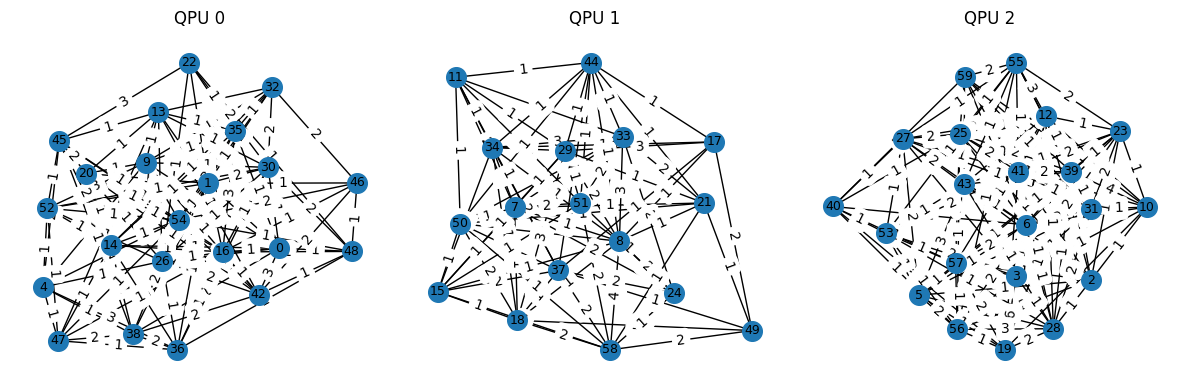

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for idx, qpu in enumerate(partition_nodes):

    nodes = partition_nodes[qpu]

    subG = G.subgraph(nodes)

    pos = nx.spring_layout(subG, seed=42)

    plt.subplot(1,3,idx+1)

    nx.draw(
        subG,
        pos,
        with_labels=True,
        node_size=200,
        font_size=9
    )

    edge_labels = nx.get_edge_attributes(subG, "weight")
    nx.draw_networkx_edge_labels(subG, pos, edge_labels=edge_labels)

    plt.title(f"QPU {qpu}")

plt.tight_layout()
plt.show()


In [24]:
communication_qubits = []

for q in G.nodes():

    for nbr in G.neighbors(q):

        if partition[nbr] != partition[q]:
            communication_qubits.append(q)
            break

print(communication_qubits)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [25]:
original_partition=list(partition)


In [26]:
# recompute local[] and link_qubit_register from scratch before lookahead
local = [0] * num_qubits
for q in range(num_qubits):
    s = 0
    for node in G.neighbors(q):
        if partition[q] == partition[node]:
            s += G[node][q]["weight"]
    local[q] = s

link_qubit_register = {}
for q in range(num_qubits):
    remote_dict = {p: 0 for p in range(num_qpu)}
    for node in G.neighbors(q):
        if partition[node] != partition[q]:
            remote_dict[partition[node]] += G[node][q]["weight"]
    link_qubit_register[q] = remote_dict

In [28]:
# Lookahead algorithm
# for q in communication_qubits:
#   max_gain=-1e9
#   max_index=-1
#   for i in range(3):   # here the partitions are only 3 but can be arbitrary for general purposes
#     if partition[q]!=i:
#       max_gain=max(max_gain,link_qubit_register[q][i])
#       if max_gain>link_qubit_register[q][i]:
#         max_index=i
#   if max_gain>local[q] and max_index!=-1:   # we can also add another if statement here to check for hardware constraints
#     shift(q,max_index,max_gain)
print(f"Starting lookahead with {len(communication_qubits)} boundary qubits")
print(f"Size partition before lookahead: {size_partition}")
print(f"Starting communication cost: {communication_cost(G, partition)}")

max_iterations = 10000
iteration      = 0
improved       = True

while improved and iteration < max_iterations:
    improved   = False
    best_gain  = float("-inf")
    best_move  = None

    # recompute boundary qubits each iteration
    communication_qubits = []
    for node in G.nodes():
        for nbr in G.neighbors(node):
            if partition[nbr] != partition[node]:
                communication_qubits.append(node)
                break

    for q in communication_qubits:
        for target in range(num_qpu):
            if target == partition[q]:
                continue
            if size_partition[target] >= qubit_capacity[target][0]:
                continue    # respect data qubit capacity
            gain = compute_gain(G, partition, q, target, alpha=1.0)
            if gain > best_gain and gain > 0:
                best_gain = gain
                best_move = (q, target)

    if best_move is not None:
        q, target = best_move
        source    = partition[q]    # save BEFORE shift()
        shift(q, target, local[q])
        size_partition[source] -= 1
        size_partition[target] += 1
        improved = True

    iteration += 1

#print(f"Communication cost after rebalancing : {rebal_cost}")
print(f"Communication cost after lookahead   : {communication_cost(G, partition)}")

print(f"Lookahead complete after {iteration} iterations")
print(f"Size partition after lookahead: {size_partition}")
print(f"Final communication cost: {communication_cost(G, partition)}")







Starting lookahead with 60 boundary qubits
Size partition before lookahead: [21, 17, 22]
Starting communication cost: 479
Communication cost after lookahead   : 479
Lookahead complete after 1 iterations
Size partition after lookahead: [21, 17, 22]
Final communication cost: 479


In [35]:
from qiskit import QuantumCircuit

# map each global qubit to its local index within its QPU
local_index = {}
qpu_qubit_lists = {p: [] for p in range(num_qpu)}
for q in range(num_qubits):
    qpu_qubit_lists[partition[q]].append(q)

for p in range(num_qpu):
    for local_i, global_q in enumerate(qpu_qubit_lists[p]):
        local_index[global_q] = local_i

# build one sub-circuit per QPU containing only local gates
local_circuits = {}
for p in range(num_qpu):
    local_circuits[p] = QuantumCircuit(len(qpu_qubit_lists[p]))

for instr in qc.data:
    if instr.operation.num_qubits == 2:
        q1 = qc.find_bit(instr.qubits[0]).index
        q2 = qc.find_bit(instr.qubits[1]).index
        if partition[q1] == partition[q2]:   # local gate
            p = partition[q1]
            local_circuits[p].append(
                instr.operation,
                [local_index[q1], local_index[q2]]
            )
    elif instr.operation.num_qubits == 1:
        q = qc.find_bit(instr.qubits[0]).index
        p = partition[q]
        local_circuits[p].append(instr.operation, [local_index[q]])

for p in range(num_qpu):
    print(f"QPU {p} sub-circuit: {len(qpu_qubit_lists[p])} qubits, "
          f"{len(local_circuits[p])} gates")
    print(local_circuits[p].draw())

QPU 0 sub-circuit: 21 qubits, 130 gates
                                                                              »
 q_0: ───────■─────────────────■───────────■──────────────────────────────────»
             │                 │           │                                  »
 q_1: ───────■────────■────────┼──■──■─────┼──────────────■───────────────────»
                      │        │  │  │     │              │                   »
 q_2: ───────■─────■──┼────────┼──┼──┼─────┼──■──■────────┼───────────────────»
             │     │  │        │  │  │     │  │  │        │                   »
 q_3: ─■─────┼─────┼──┼────────┼──┼──┼──■──■──┼──■────────┼─────────────────■─»
       │     │     │  │        │  │  │  │     │           │                 │ »
 q_4: ─┼─────┼─────┼──┼────────┼──┼──■──┼─────┼─────■─────┼─────────────────┼─»
       │     │     │  │        │  │     │     │     │     │                 │ »
 q_5: ─┼─────┼─────┼──┼──■─────┼──┼─────┼──■──┼─────┼──■──┼──────────────■──┼─»


In [29]:
from collections import defaultdict

inter_qpu_gates = defaultdict(list)

for i in qc.data:
    if i.operation.num_qubits == 2:
        qubits = i.qubits
        q1 = qc.find_bit(qubits[0]).index
        q2 = qc.find_bit(qubits[1]).index
        if partition[q1] != partition[q2]:
            qpu1 = partition[q1]
            qpu2 = partition[q2]
            key = (min(qpu1, qpu2), max(qpu1, qpu2)) # (a,b) and (b,a) should be considered as one key only
            inter_qpu_gates[key].append((q1, q2))

# print summary
for pair, gates in inter_qpu_gates.items():
    print(f"QPU{pair[0]} - QPU{pair[1]}: {len(gates)} inter-QPU gates")
    print(f"  Gates: {gates}")


QPU0 - QPU1: 137 inter-QPU gates
  Gates: [(14, 35), (30, 36), (36, 1), (36, 38), (36, 4), (44, 42), (13, 58), (52, 14), (50, 53), (58, 22), (47, 51), (45, 14), (47, 14), (45, 14), (37, 13), (50, 16), (52, 34), (8, 32), (16, 34), (7, 54), (30, 24), (36, 38), (14, 54), (53, 34), (29, 35), (34, 0), (36, 26), (14, 20), (32, 7), (4, 33), (45, 8), (20, 8), (24, 26), (4, 51), (20, 7), (13, 21), (48, 36), (8, 13), (46, 33), (14, 0), (38, 14), (11, 53), (37, 53), (1, 8), (24, 1), (13, 18), (29, 53), (48, 11), (51, 48), (4, 36), (38, 15), (34, 52), (54, 33), (7, 13), (26, 33), (37, 52), (38, 58), (24, 54), (22, 33), (46, 15), (26, 33), (52, 51), (18, 48), (36, 47), (24, 38), (1, 8), (34, 30), (38, 7), (33, 0), (9, 33), (20, 34), (21, 38), (53, 29), (33, 42), (29, 9), (37, 47), (33, 0), (44, 30), (21, 35), (9, 21), (47, 29), (58, 54), (30, 50), (42, 21), (24, 48), (35, 50), (26, 37), (38, 8), (4, 15), (18, 45), (30, 51), (0, 21), (32, 29), (18, 54), (16, 51), (53, 34), (9, 24), (51, 32), (46, 51

In [30]:
def get_layers(gates, channel_capacity):
    layers = []
    remaining_gates = list(gates)

    while remaining_gates:
        current_layer = []
        used_qubits = set()
        gates_to_remove = []

        for gate_idx, gate in enumerate(remaining_gates):
            q1, q2 = gate
            if q1 not in used_qubits and q2 not in used_qubits and len(current_layer) < channel_capacity:
                current_layer.append(gate)
                used_qubits.add(q1)
                used_qubits.add(q2)
                gates_to_remove.append(gate_idx)

        for idx in sorted(gates_to_remove, reverse=True):
            remaining_gates.pop(idx)

        if current_layer:
            layers.append(current_layer)

    return layers

# Layered inter-QPU gates
print("Layered inter-QPU gates:")
layered_inter_qpu_gates = {}

for pair, gates in inter_qpu_gates.items():
    channel_capacity = min(qubit_capacity[pair[0]][1], qubit_capacity[pair[1]][1])
    print(f"\nQPU{pair[0]} - QPU{pair[1]} (channel capacity={channel_capacity}):")
    layers = get_layers(gates, channel_capacity)
    layered_inter_qpu_gates[pair] = layers
    for i, layer in enumerate(layers):
        print(f"  Layer {i+1}: {layer}")

print(" ")
print("Final Result: ")
for pair, layers in layered_inter_qpu_gates.items():
    channel_capacity = min(qubit_capacity[pair[0]][1], qubit_capacity[pair[1]][1])
    print(f"QPU{pair[0]} ↔ QPU{pair[1]}: "
          f"{len(inter_qpu_gates[pair])} inter-QPU gates | "
          f"{len(layers)} communication rounds needed | "
          f"channel capacity={channel_capacity}")

print(f"\nTotal communication cost: {communication_cost(G, partition)}")

Layered inter-QPU gates:

QPU0 - QPU1 (channel capacity=20):
  Layer 1: [(14, 35), (30, 36), (44, 42), (13, 58), (50, 53), (47, 51), (52, 34), (8, 32), (7, 54), (4, 33), (24, 26), (48, 11), (38, 15), (29, 9), (18, 45), (0, 21)]
  Layer 2: [(36, 1), (52, 14), (58, 22), (37, 13), (50, 16), (30, 24), (53, 34), (29, 35), (32, 7), (45, 8), (4, 51), (46, 33), (18, 48), (21, 38), (54, 15)]
  Layer 3: [(36, 38), (45, 14), (16, 34), (20, 8), (13, 21), (11, 53), (24, 1), (51, 48), (54, 33), (37, 52), (46, 15), (44, 30), (47, 29), (35, 50), (18, 4)]
  Layer 4: [(36, 4), (47, 14), (34, 0), (20, 7), (8, 13), (37, 53), (26, 33), (38, 58), (24, 54), (52, 51), (21, 35), (30, 50), (32, 29), (45, 15), (11, 22), (18, 1), (46, 44)]
  Layer 5: [(45, 14), (36, 38), (1, 8), (13, 18), (29, 53), (34, 52), (22, 33), (37, 47), (9, 21), (58, 54), (24, 48), (4, 15), (30, 51)]
  Layer 6: [(14, 54), (36, 26), (7, 13), (24, 38), (1, 8), (34, 30), (33, 0), (53, 29), (42, 21), (16, 51), (45, 44), (48, 58), (11, 52), (4

In [31]:
import networkx as nx

G = nx.convert_node_labels_to_integers(G)

partition_nodes = {}

for p in range(num_qpu):
    partition_nodes[p] = [i for i in range(len(partition)) if partition[i] == p]

print(partition_nodes)


{0: [0, 1, 4, 9, 13, 16, 20, 22, 26, 30, 32, 35, 38, 42, 45, 46, 47, 48, 52, 53, 54], 1: [7, 8, 11, 14, 15, 18, 21, 24, 29, 33, 34, 36, 37, 44, 50, 51, 58], 2: [2, 3, 5, 6, 10, 12, 17, 19, 23, 25, 27, 28, 31, 39, 40, 41, 43, 49, 55, 56, 57, 59]}


In [32]:
# original communication cost
print(communication_cost(G,original_partition))

487


In [33]:
# cost after lookahead
print(communication_cost(G,partition))

479


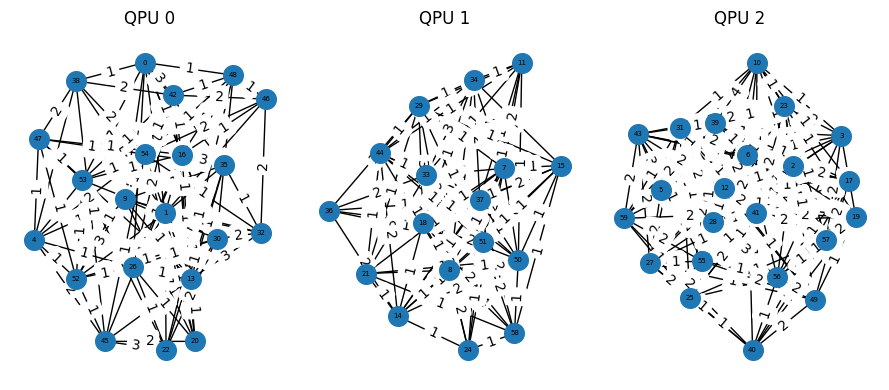

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))

for idx, qpu in enumerate(partition_nodes):

    nodes = partition_nodes[qpu]

    subG = G.subgraph(nodes)

    pos = nx.spring_layout(subG, seed=42)

    plt.subplot(1,3,idx+1)

    nx.draw(
        subG,
        pos,
        with_labels=True,
        node_size=200,
        font_size=5
    )

    edge_labels = nx.get_edge_attributes(subG, "weight")
    nx.draw_networkx_edge_labels(subG, pos, edge_labels=edge_labels)

    plt.title(f"QPU {qpu}")

plt.tight_layout()
plt.show()
